In [1]:
import numpy as np
import sys
import os
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass

In [2]:
sys.path.append(os.path.abspath('../library'))
import data as d
import preprocess as p
import utils as u
import bayes as b
import pipeline
import results as r
import figures as figs

#### 0. Load data

In [3]:
spikeprob, spikes, position_mtx, darktrials, deltrials = d.load_data('C57_61_Priamus', tau=0.2)

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_61_Priamus/time_binned_SpikeInf_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_61_Priamus/time_binned_DiscreteSpikes_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_61_Priamus/target_positions_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_61_Priamus/darktrial_raw.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_61_Priamus/del_trials.mat loaded with mat73.loadmat


#### 1. Align axes

In [4]:
spikeprob, spikes, darktrials = p.align_axes(spikeprob, spikes, darktrials)

print(spikeprob.shape)
print(spikes.shape)
print(darktrials.shape)

(230, 153, 145)
(230, 153, 145)
(230, 1)


In [5]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.14299583010811756
mean in light: 0.14814079475673123
mean in dark: 0.13223126457371404
98 out of 145 are higher in light

Spikeprob
mean all: 0.02636206612002578
mean in light: 0.026499823913635135
mean in dark: 0.026048961754314787
84 out of 145 are higher in light


#### 2. Format position index and Remove deleted trials

In [6]:
# Priamus
deltrials = np.append(deltrials, [79, 157])

In [7]:
position_mtx, deltrials = p.format_pos_idx(position_mtx, deltrials)
spikeprob, spikes, position_mtx, darktrials = p.remove_deleted_trials(spikeprob, spikes, position_mtx, darktrials, deltrials)

print(spikeprob.shape)
print(spikes.shape)
print(position_mtx.shape)
print(darktrials.shape)
print(deltrials.shape)

(214, 153, 145)
(214, 153, 145)
(214, 153)
(214, 1)
(16,)


In [8]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.1443277166673533
mean in light: 0.1493485342019544
mean in dark: 0.13342623964602696
95 out of 145 are higher in light

Spikeprob
mean all: 0.026279686184374196
mean in light: 0.02633713993168357
mean in dark: 0.026142898783342097
83 out of 145 are higher in light


#### 3. Remove non-nan neurons, match nans, and correct pos artefacts

In [9]:
spikeprob, spikes = p.remove_nonnan_neuron(spikeprob, spikes)
spikes = p.match_nan_from_spikeprob(spikeprob, spikes)
position_mtx = p.remove_pos_artefacts(position_mtx)

print(spikeprob.shape)
print(spikes.shape)
print(position_mtx.shape)

(214, 153, 143)
(214, 153, 143)
(214, 153)


In [10]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.17918358164764736
mean in light: 0.18023062746750612
mean in dark: 0.17669074726925968
80 out of 143 are higher in light

Spikeprob
mean all: 0.026541761889516107
mean in light: 0.02659589846462896
mean in dark: 0.02641287209977637
82 out of 143 are higher in light


#### 4. Masking spikes

In [11]:
rewardzone = [46,47,48,49]
firstx_pos = u.get_firstx_pos(position_mtx, 5)
mask = u.create_spikesmask(spikes, position_mtx, spikeprob, rewardzone, firstx_pos)
position_mtx_masked = u.mask_position_mtx(position_mtx, rewardzone, firstx_pos)
print(np.nanmin(position_mtx_masked))
print(np.nanmax(position_mtx_masked))

spikes_masked = u.mask_spikes(spikes, mask)
spikeprob_masked = u.mask_spikes(spikeprob, mask)

smallest first position: 4.0
largest first position: 36.0
0.0
60.0


In [12]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.17918358164764736
mean in light: 0.18023062746750612
mean in dark: 0.17669074726925968
80 out of 143 are higher in light

Spikeprob
mean all: 0.026541761889516107
mean in light: 0.02659589846462896
mean in dark: 0.02641287209977637
82 out of 143 are higher in light


#### Plot single tuning

In [13]:
neuron_idx = np.random.randint(0, num_neurons)
# neuron_idx = 83
# neuron_idx = 29
neuron_idx = 109
print(neuron_idx)

109


In [ ]:
fr = u.posbinning_data(spikes_masked, 'spikes', position_mtx_masked, 50, 0.2)
fr_light, fr_dark = u.split_lightdark(fr, darktrials)

spikeprob_pbin = u.posbinning_data(spikeprob_masked, 'spikeprob', position_mtx_masked, 50, 0.2)
spikeprob_pbin_light, spikeprob_pbin_dark = u.split_lightdark(spikeprob_pbin, darktrials)


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


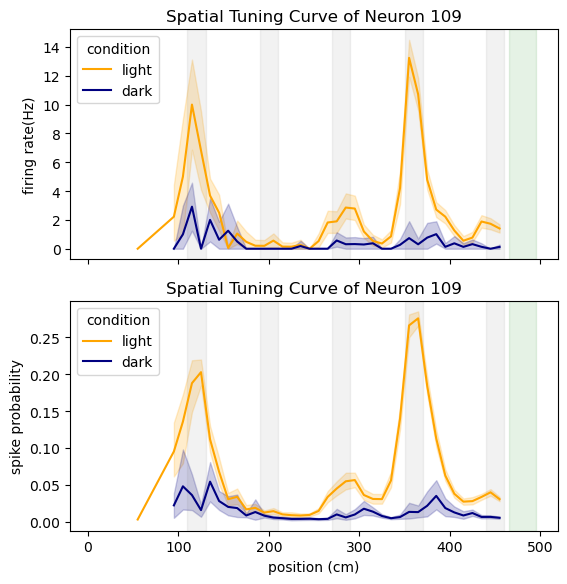

In [14]:
fr = u.posbinning_data(spikes_masked, 'spikes', position_mtx_masked, 50, 0.2)
num_trials, num_pbins, num_neurons = fr.shape
fr_light, fr_dark = u.split_lightdark(fr, darktrials)

# Generate Data Frame
position_all_spikes = np.tile(np.arange(num_pbins), fr.shape[0])
condition_all_spikes = np.array(
    ['light'] * fr_light.shape[0] * num_pbins + 
    ['dark'] * fr_dark.shape[0] * num_pbins
)
data_all_spikes = np.concatenate(
    (fr_light[:,:,neuron_idx].flatten(), 
        fr_dark[:,:,neuron_idx].flatten())
)    
df_spikes = pd.DataFrame(
    {'position':position_all_spikes, 'condition':condition_all_spikes, 'activity':data_all_spikes}
)


spikeprob_pbin = u.posbinning_data(spikeprob_masked, 'spikeprob', position_mtx_masked, 50, 0.2)
num_trials, num_pbins, num_neurons = spikeprob_pbin.shape
spikeprob_pbin_light, spikeprob_pbin_dark = u.split_lightdark(spikeprob_pbin, darktrials)

# Generate Data Frame
position_all_spikeprob = np.tile(np.arange(num_pbins), spikeprob_pbin.shape[0])
condition_all_spikeprob = np.array(
    ['light'] * spikeprob_pbin_light.shape[0] * num_pbins + 
    ['dark'] * spikeprob_pbin_dark.shape[0] * num_pbins
)
data_all_spikeprob = np.concatenate(
    (spikeprob_pbin_light[:,:,neuron_idx].flatten(), 
        spikeprob_pbin_dark[:,:,neuron_idx].flatten())
)    
df_spikeprob = pd.DataFrame(
    {'position':position_all_spikeprob, 'condition':condition_all_spikeprob, 'activity':data_all_spikeprob}
)




# Initialise figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6), sharex=True)
fig.tight_layout(pad=2.5, h_pad=2)

# Initialise figure settings
ax_settings = {'title':'Spatial Tuning Curve of Neuron {}'.format(neuron_idx), 
                'xlabel':'position (cm)',
                'xticks':[-0.5, 9.5, 19.5, 29.5, 39.5, 49.5],
                'xticklabels':[0, 100, 200, 300, 400, 500]}

# Plot
ax1 = sns.lineplot(data=df_spikes, x ='position', y='activity', hue='condition', palette=['orange','navy'], ax=ax1)
ax2 = sns.lineplot(data=df_spikeprob, x ='position', y='activity', hue='condition', palette=['orange','navy'], ax=ax2)


ax1.set(ylabel = 'firing rate(Hz)', **ax_settings)
ax2.set(ylabel ='spike probability', **ax_settings)



# Specify landmarks and reward zones
landmark = [(10.5,12.5), (18.5,20.5), (26.5,28.5), (34.5,36.5), (43.5,45.5)]
rewardzone = (46, 49)

for coord in landmark:
    ax1.axvspan(coord[0], coord[1], alpha=0.1, color='grey')
    ax2.axvspan(coord[0], coord[1], alpha=0.1, color='grey')

ax1.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')
ax2.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')

ax1.axvline(0, linewidth=1, color="white")
ax2.axvline(0, linewidth=1, color="white")

    
plt.show()

In [65]:
np.nanmean(fr_dark[:,:,109], axis=0)

/var/folders/f6/9tvrjkdn24b4mjg8c_xtrc8c0000gn/T/ipykernel_42358/2027586448.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(fr_dark[:,:,109], axis=0)


array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 0.        ,
       1.        , 2.91666667, 0.        , 2.        , 0.625     ,
       1.25      , 0.5       , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.18518519, 0.        ,
       0.        , 0.        , 0.57142857, 0.3125    , 0.32258065,
       0.29411765, 0.37878788, 0.        , 0.        , 0.27027027,
       0.73529412, 0.30701754, 0.76923077, 1.01190476, 0.13157895,
       0.375     , 0.12820513, 0.31914894, 0.13333333, 0.        ,
       0.12681159,        nan,        nan,        nan,        nan])

In [64]:
np.nanmean(fr_light[:,:,109], axis=0)

/var/folders/f6/9tvrjkdn24b4mjg8c_xtrc8c0000gn/T/ipykernel_42358/3408101052.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(fr_light[:,:,109], axis=0)


array([        nan,         nan,         nan,         nan,         nan,
        0.        ,         nan,         nan,         nan,  2.22222222,
        5.        , 10.        ,  6.81818182,  3.68421053,  2.5       ,
        0.05263158,  1.05072464,  0.47619048,  0.20833333,  0.2       ,
        0.5625    ,  0.14705882,  0.13888889,  0.26785714,  0.        ,
        0.53191489,  1.82017544,  1.9       ,  2.85714286,  2.78680371,
        1.19594595,  0.53571429,  0.36231884,  0.85714286,  4.21348315,
       13.24324324, 10.71428571,  4.78741497,  2.71590909,  2.22348485,
        1.2654321 ,  0.55555556,  0.77217125,  1.8879056 ,  1.73228346,
        1.40398352,         nan,         nan,         nan,         nan])

In [68]:
np.where(~np.isnan(fr_light[:,5,109]))

(array([4]),)

In [74]:
pos_light, pos_dark = u.split_lightdark(position_mtx, darktrials)
print(pos_light[4])
print(pos_light[15])

[nan nan nan nan nan nan nan nan nan  8.  8.  8.  8.  8.  8.  8.  8.  8.
  8.  9.  9. 10. 10. 11. 12. 12. 13. 14. 15. 16. 17. 17. 19. 20. 20. 21.
 22. 23.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0. nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan 32. 33. 34. 35. 37. 38. 39. 39. 40.
 41. 42. 43. 44. 45. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46.
 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 47. 47. 49. 51. 53. 56. 58.
 59. nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan 

In [73]:
pos_light_masked, pos_dark_masked = u.split_lightdark(position_mtx_masked, darktrials)
print(pos_light_masked[4])

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan 13. 14. 15. 16. 17. 17. 19. 20. 20. 21.
 22. 23.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0. nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]


In [69]:
fr_light[4,:,109]

array([nan, nan, nan, nan, nan,  0., nan, nan, nan, nan, nan, nan, nan,
        5.,  0.,  0.,  0.,  0., nan,  0.,  0.,  0.,  0.,  0., nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

#### Trial by trial plot

trial: 0 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


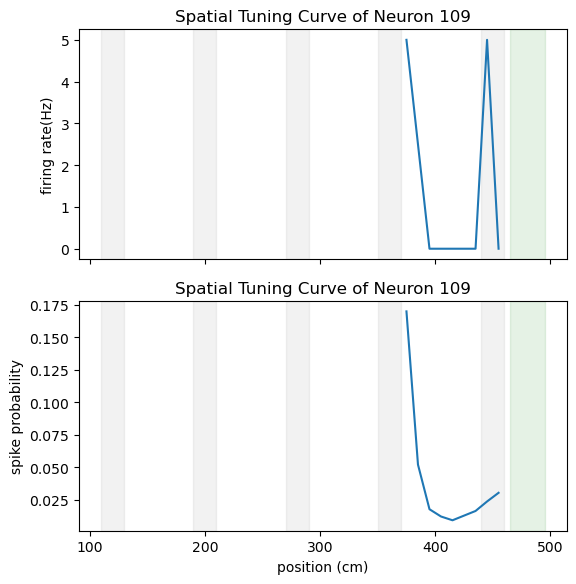

trial: 1 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


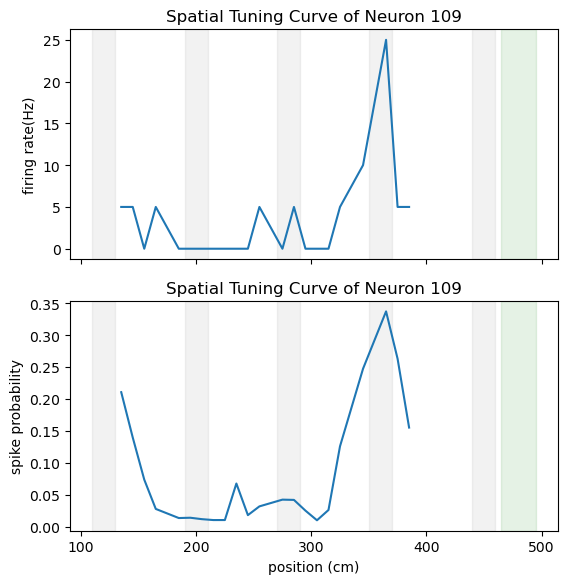

trial: 2 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


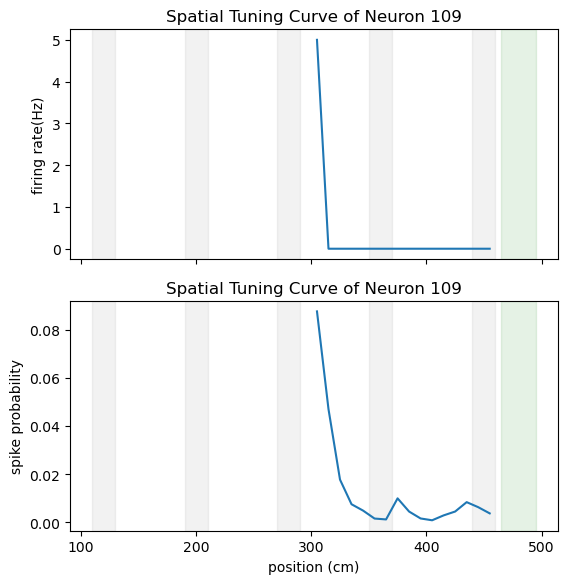

trial: 3 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


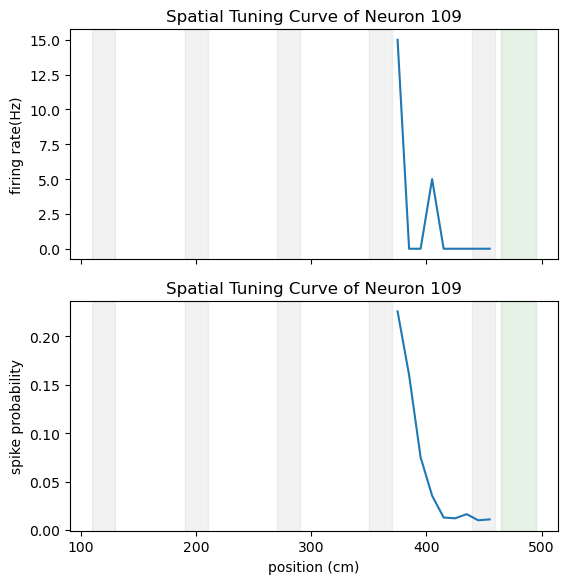

trial: 4 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


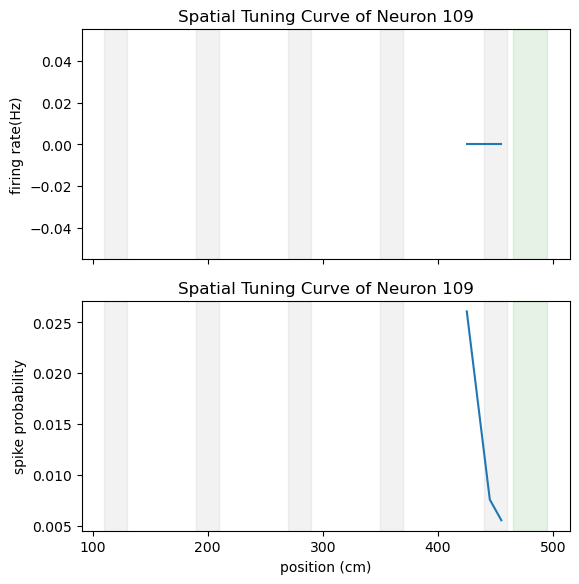

trial: 5 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


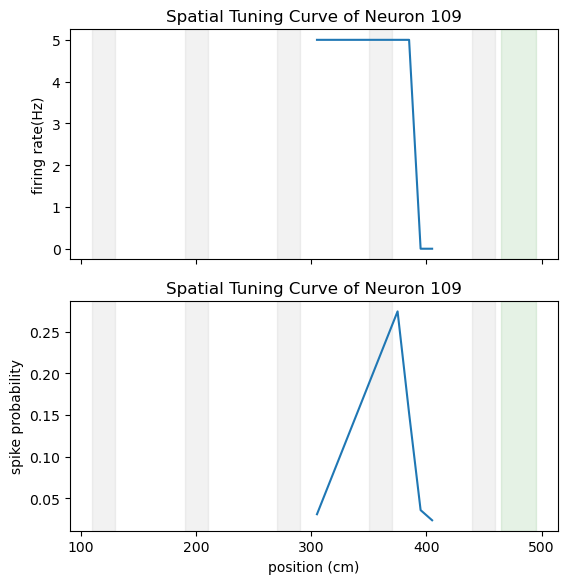

trial: 6 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


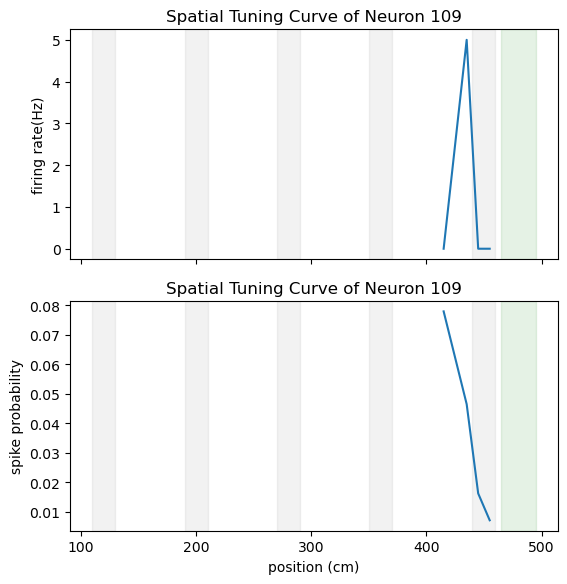

trial: 7 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


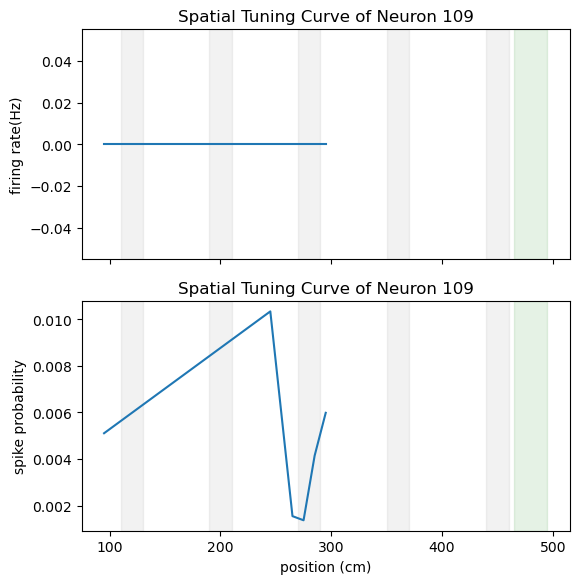

trial: 8 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


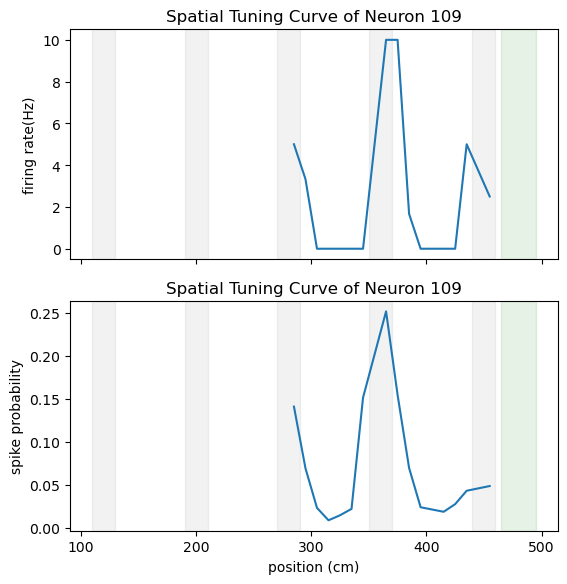

trial: 9 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


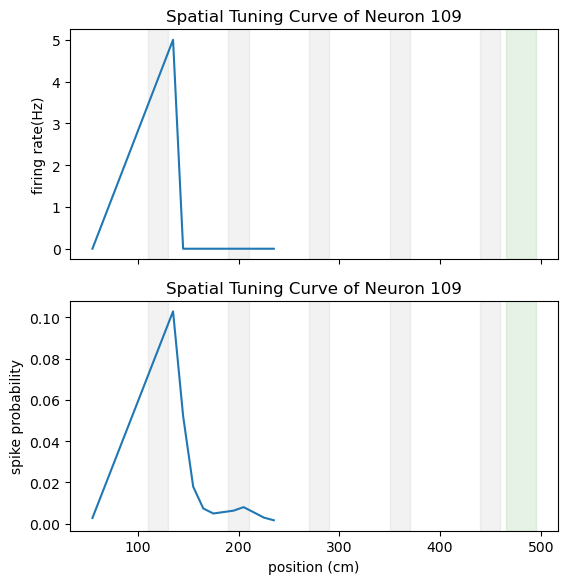

trial: 10 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


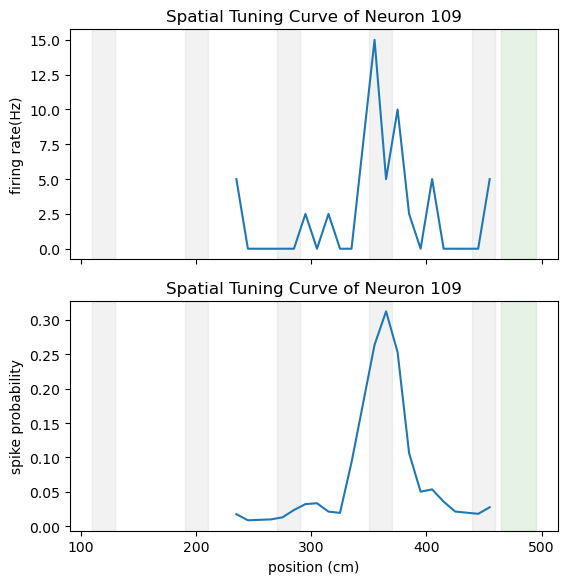

trial: 11 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


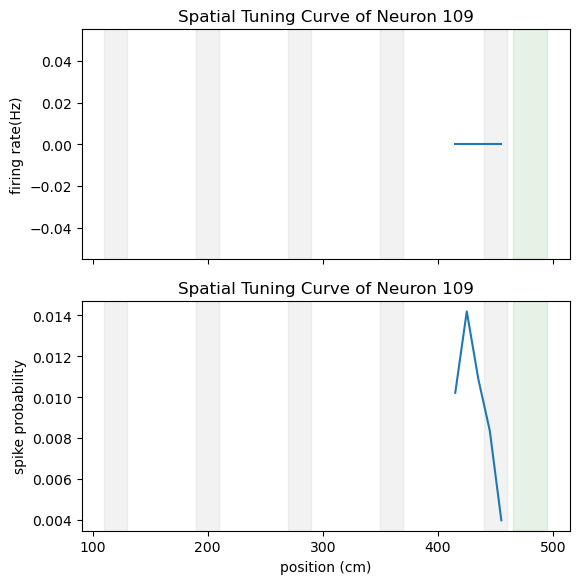

trial: 12 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


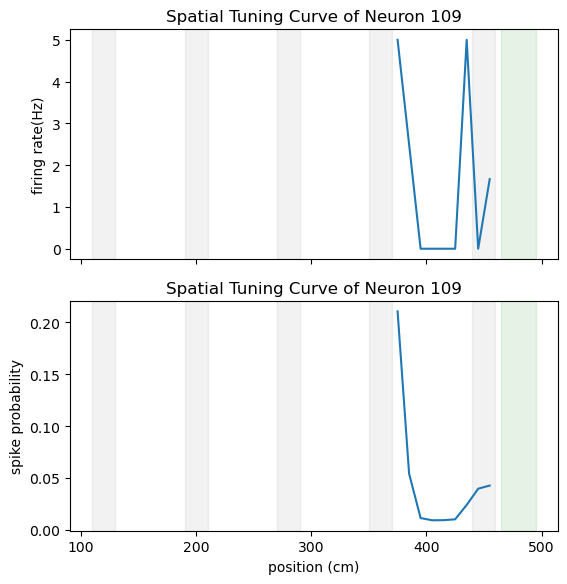

trial: 13 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


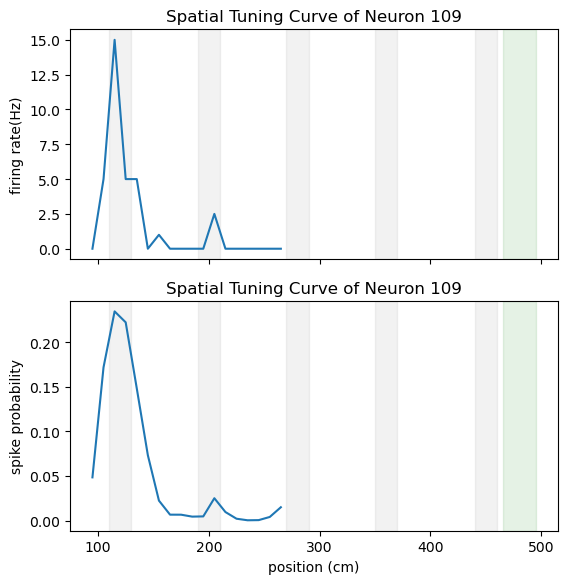

trial: 14 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


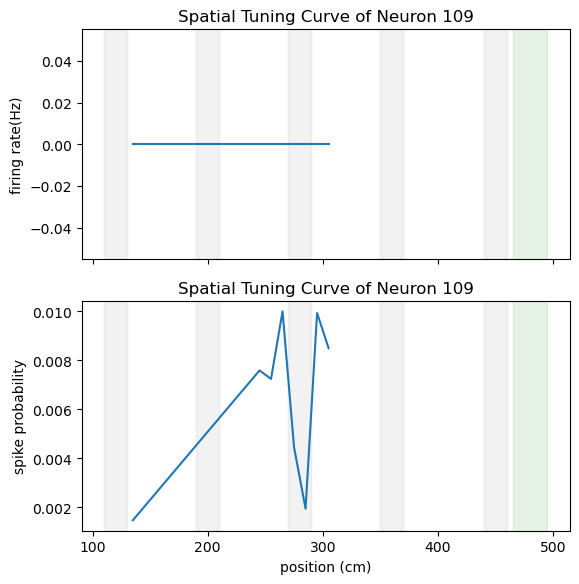

trial: 15 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


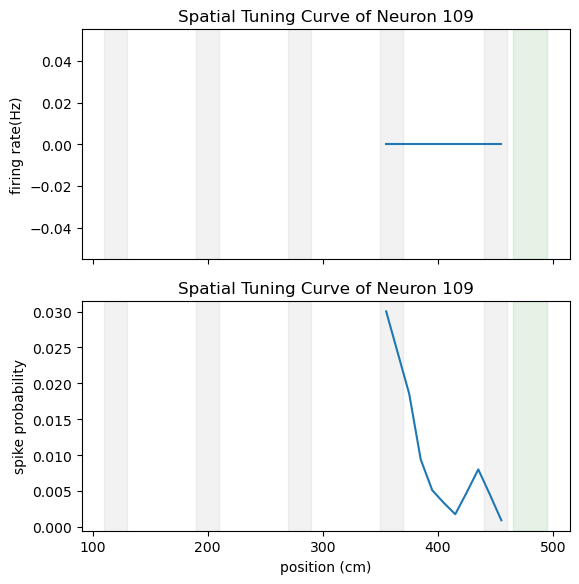

trial: 16 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


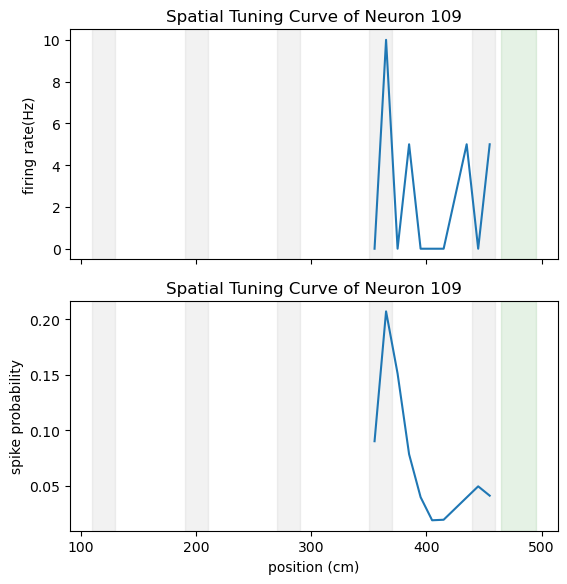

trial: 17 light


KeyboardInterrupt: 

In [15]:
num_trials, num_pbins, num_neurons = fr.shape

for trial in range(num_trials):
    if darktrials[trial] == 0:
        print("trial:", trial, 'light')
    else:
        print("trial:", trial, 'dark')

    spikes_pbin = u.posbinning_data(spikes, 'spikes', position_mtx_masked, 50, 0.2)

    # Generate Data Frame
    position_all_spikes = np.tile(np.arange(num_pbins), 1)
    data_all_spikes = spikes_pbin[trial,:,neuron_idx].flatten()

    df_spikes_trial = pd.DataFrame(
        {'position':position_all_spikes, 'activity':data_all_spikes}
    )


    spikeprob_pbin = u.posbinning_data(spikeprob, 'spikeprob', position_mtx_masked, 50, 0.2)

    # Generate Data Frame
    position_all_spikeprob = np.tile(np.arange(num_pbins), 1)
    data_all_spikeprob = spikeprob_pbin[trial,:,neuron_idx].flatten()
      
    df_spikeprob_trial = pd.DataFrame(
        {'position':position_all_spikeprob, 'activity':data_all_spikeprob}
    )




    # Initialise figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6), sharex=True)
    fig.tight_layout(pad=2.5, h_pad=2)

    # Initialise figure settings
    ax_settings = {'title':'Spatial Tuning Curve of Neuron {}'.format(neuron_idx), 
                    'xlabel':'position (cm)',
                    'xticks':[-0.5, 9.5, 19.5, 29.5, 39.5, 49.5],
                    'xticklabels':[0, 100, 200, 300, 400, 500]}

    # Plot
    ax1 = sns.lineplot(data=df_spikes_trial, x ='position', y='activity', ax=ax1)
    ax2 = sns.lineplot(data=df_spikeprob_trial, x ='position', y='activity', ax=ax2)


    ax1.set(ylabel = 'firing rate(Hz)', **ax_settings)
    ax2.set(ylabel ='spike probability', **ax_settings)



    # Specify landmarks and reward zones
    landmark = [(10.5,12.5), (18.5,20.5), (26.5,28.5), (34.5,36.5), (43.5,45.5)]
    rewardzone = (46, 49)

    for coord in landmark:
        ax1.axvspan(coord[0], coord[1], alpha=0.1, color='grey')
        ax2.axvspan(coord[0], coord[1], alpha=0.1, color='grey')

    ax1.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')
    ax2.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')
        
    plt.show()